In [1]:
!pip install kmodes

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.spatial.distance import cdist, hamming
from scipy.cluster.hierarchy import dendrogram, linkage
from kmodes.kmodes import KModes

In [3]:
from sklearn.datasets import load_wine

data = load_wine()
X = data.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset shape:", X.shape)
print("Features:", data.feature_names)

Dataset shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [4]:
p1 = X_scaled[0]
p2 = X_scaled[1]

euclidean = np.sqrt(np.sum((p1 - p2)**2))
print("a) Euclidean Distance:", round(euclidean, 4))


a) Euclidean Distance: 3.4975


In [5]:
manhattan = np.sum(np.abs(p1 - p2))
print("b) Manhattan Distance:", round(manhattan, 4))

b) Manhattan Distance: 9.4557


In [6]:
max_norm = np.max(np.abs(p1 - p2))
print("c) Maximum Norm (Chebyshev):", round(max_norm, 4))

c) Maximum Norm (Chebyshev): 1.8958


In [7]:
cov_matrix = np.cov(X_scaled.T)
inv_cov = np.linalg.inv(cov_matrix)
diff = p1 - p2
mahal = np.sqrt(diff @ inv_cov @ diff.T)
print("d) Mahalanobis Distance:", round(mahal, 4))

d) Mahalanobis Distance: 3.9412


In [8]:
dot_product = np.dot(p1, p2)
inner = dot_product / (np.linalg.norm(p1) * np.linalg.norm(p2))
print("e) Inner Product (Cosine Similarity):", round(inner, 4))

e) Inner Product (Cosine Similarity): 0.5623


In [9]:
X_binary = (X_scaled > 0).astype(int)
b1 = X_binary[0]
b2 = X_binary[1]
hamming_dist = hamming(b1, b2)
print("f) Hamming Distance:", round(hamming_dist, 4))


f) Hamming Distance: 0.2308


In [13]:
# Load dataset
wine = load_wine()
X = wine.data

# Convert to DataFrame with correct feature names
X_cat = pd.DataFrame(X, columns=wine.feature_names)

# Convert numerical → categorical
for col in X_cat.columns:
    X_cat[col] = pd.cut(X_cat[col], bins=3, labels=['low','mid','high'])

# Apply K-Modes
km = KModes(n_clusters=3, init='Huang', random_state=42)
labels_kmode = km.fit_predict(X_cat)

print("K-Mode cluster labels (first 10):", labels_kmode[:10])
print("K-Mode cluster counts:", np.bincount(labels_kmode))

K-Mode cluster labels (first 10): [2 2 2 2 0 2 2 0 2 2]
K-Mode cluster counts: [78 54 46]


In [14]:
agnes_single = AgglomerativeClustering(n_clusters=3, linkage='single')
labels_single = agnes_single.fit_predict(X_scaled)
print("AGNES Single - Silhouette:", round(silhouette_score(X_scaled, labels_single), 4))


AGNES Single - Silhouette: 0.1827


In [15]:
agnes_complete = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels_complete = agnes_complete.fit_predict(X_scaled)
print("AGNES Complete - Silhouette:", round(silhouette_score(X_scaled, labels_complete), 4))

AGNES Complete - Silhouette: 0.2038


In [16]:
agnes_ward = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_ward = agnes_ward.fit_predict(X_scaled)
print("AGNES Ward - Silhouette:", round(silhouette_score(X_scaled, labels_ward), 4))

AGNES Ward - Silhouette: 0.2774


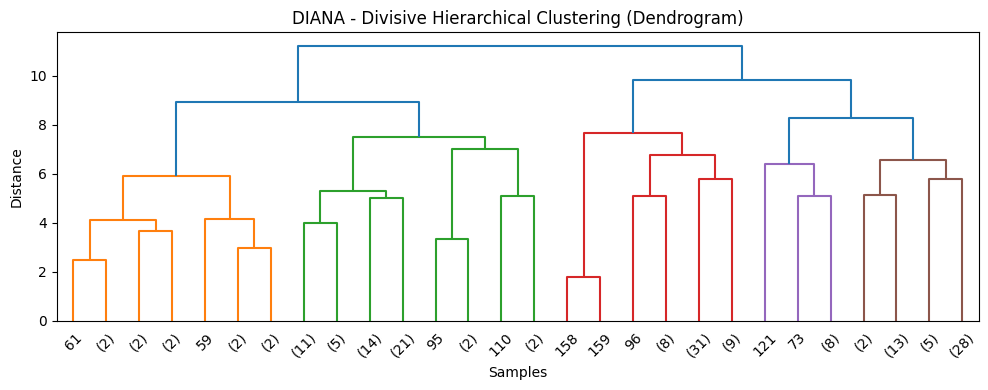

In [17]:
Z = linkage(X_scaled, method='complete')
plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='level', p=4)
plt.title("DIANA - Divisive Hierarchical Clustering (Dendrogram)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [18]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise    = list(labels_dbscan).count(-1)
print("DBSCAN Clusters found:", n_clusters)
print("DBSCAN Noise points:  ", n_noise)

# Only compute silhouette if more than 1 cluster
if n_clusters > 1:
    mask = labels_dbscan != -1
    print("DBSCAN Silhouette:", round(silhouette_score(X_scaled[mask], labels_dbscan[mask]), 4))

DBSCAN Clusters found: 0
DBSCAN Noise points:   178


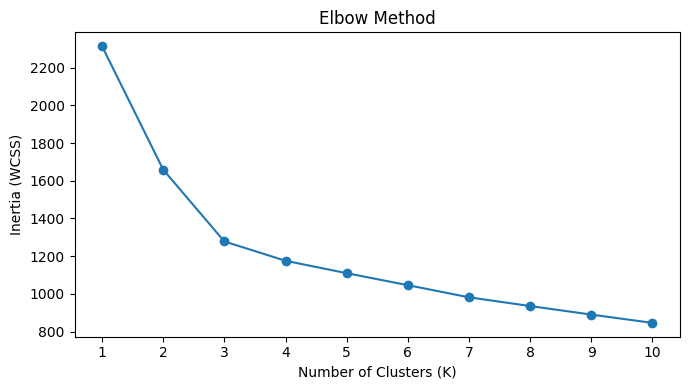

In [19]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.xticks(k_range)
plt.tight_layout()
plt.show()


Best K by Silhouette: 3
Best Silhouette Score: 0.2849


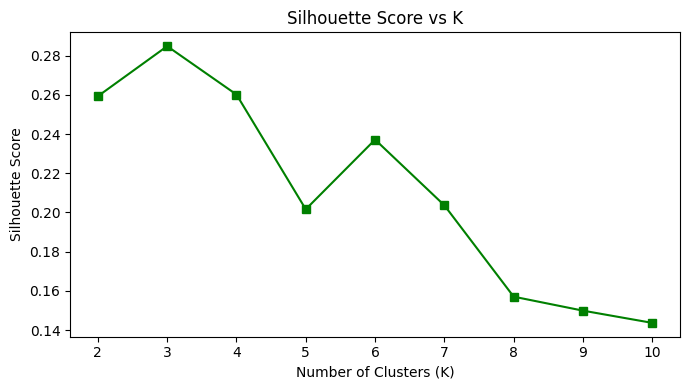

In [20]:
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = np.argmax(sil_scores) + 2
print("Best K by Silhouette:", best_k)
print("Best Silhouette Score:", round(max(sil_scores), 4))

plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), sil_scores, marker='s', color='green')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()



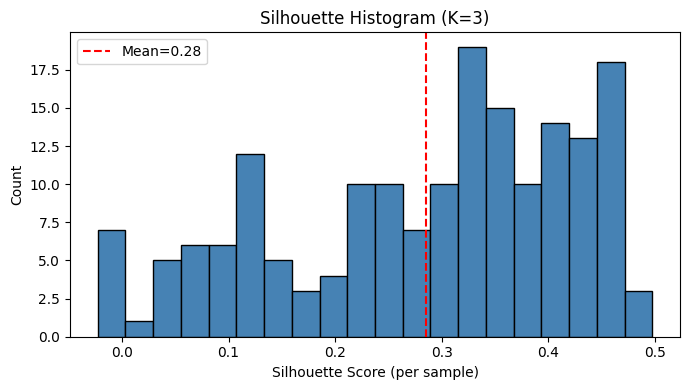

In [21]:
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_best = km_best.fit_predict(X_scaled)
sil_vals = silhouette_samples(X_scaled, labels_best)

plt.figure(figsize=(7, 4))
plt.hist(sil_vals, bins=20, color='steelblue', edgecolor='black')
plt.axvline(x=np.mean(sil_vals), color='red', linestyle='--', label=f'Mean={np.mean(sil_vals):.2f}')
plt.xlabel("Silhouette Score (per sample)")
plt.ylabel("Count")
plt.title(f"Silhouette Histogram (K={best_k})")
plt.legend()
plt.tight_layout()
plt.show()